# Glint Arc Flight Planning

Arc-shaped flight paths for maximizing specular solar glint on offshore targets.

To capture maximum glint, the sensor view zenith angle (VZA) must equal the solar zenith angle (SZA), and the sensor, sun, and target must lie in the same principal plane. The aircraft flies a **180 degree banked turn** at a bank angle equal to the SZA, tilting a nadir-pointing sensor to achieve the specular reflection geometry. At the arc midpoint (90 degrees into the turn), the glint angle reaches zero -- perfect specular reflection. The aircraft enters the turn on one heading and exits on the reciprocal.

The geometry is derived from **optics first, then kinematics**:
1. Specular reflection places the aircraft along the solar azimuth from the target
2. The turn center is on the **opposite side** of the aircraft from the target (toward the sun), guaranteeing the target is always **outside** the turn circle
3. The arc is constructed around that center

The bank angle defaults to SZA when SZA <= 60 degrees. For steeper sun angles (e.g., early morning, high latitudes), an explicit `bank_angle` must be provided.

This notebook demonstrates:
1. Creating a `GlintArc` for an offshore oil/gas platform target
2. Visualizing the arc geometry and verifying the target is outside the arc
3. Controlling arc extent with `collection_length`
4. Computing and mapping glint angles across the sensor swath
5. Exploring how time of day affects the arc geometry
6. Comparing left vs. right bank directions
7. Generating approach and exit `FlightLine` objects for the complete route
8. Computing the sensor swath ground footprint polygon
9. Exporting to GeoJSON and TrackAir

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import folium
from datetime import datetime, timezone, timedelta

from hyplan.glint import GlintArc, compute_glint_arc
from hyplan.instruments import AVIRIS3
from hyplan.units import ureg
from pymap3d.vincenty import vdist

## 1. Create a Glint Arc

Define a target (offshore platform in the Gulf of Mexico) and observation parameters. The `GlintArc` computes the solar geometry, required bank angle, turn radius, and arc flight path automatically.

In [2]:
# Offshore platform in the Gulf of Mexico
target_lat = 28.98
target_lon = -89.00

# Observation at 17:00 UTC (noon local CDT)
obs_time = datetime(2025, 6, 15, 17, 0, tzinfo=timezone.utc)

arc = GlintArc(
    target_lat=target_lat,
    target_lon=target_lon,
    observation_datetime=obs_time,
    altitude_msl=ureg.Quantity(10000, "foot"),
    speed=ureg.Quantity(145, "knot"),
    site_name="GOM Platform",
)

print(f"Solar zenith:        {arc.solar_zenith:.1f}")
print(f"Solar azimuth:       {arc.solar_azimuth:.1f}")
print(f"Bank angle:          {arc.bank_angle:.1f}  ({'auto from SZA' if arc.bank_angle == arc.solar_zenith else 'user override'})")
print(f"Turn radius:         {arc.turn_radius.to('meter'):.0f}")
print(f"Heading at midpoint: {arc.heading_at_midpoint:.1f}")
print(f"Arc length:          {arc.length.to('km'):.2f}")
print(f"Duration:            {arc.duration.to('second'):.0f}")

Solar zenith:        13.9
Solar azimuth:       110.7
Bank angle:          13.9  (auto from SZA)
Turn radius:         2296 meter
Heading at midpoint: 200.7
Arc length:          7.21 kilometer
Duration:            97 second


## 2. Visualize the Arc on an Interactive Map

Display the arc flight path along with the target platform location. The turn center is on the opposite side of the aircraft from the target, so the target is always outside the arc.

In [3]:
m = folium.Map(location=[target_lat, target_lon], zoom_start=12)

# Arc flight path
arc_coords = [(lat, lon) for lon, lat in arc.geometry.coords]
folium.PolyLine(
    arc_coords, color="blue", weight=3,
    tooltip=f"Glint Arc: bank={arc.bank_angle:.1f}, R={arc.turn_radius.to('km'):.2f}",
).add_to(m)

# Target platform
folium.Marker(
    [target_lat, target_lon],
    popup=f"Target: {arc.site_name}",
    icon=folium.Icon(color="red", icon="industry", prefix="fa"),
).add_to(m)

# Aircraft midpoint (where glint is perfect)
folium.CircleMarker(
    [arc._aircraft_mid_lat, arc._aircraft_mid_lon],
    radius=5, color="green", fill=True,
    tooltip=f"Aircraft at arc midpoint (heading {arc.heading_at_midpoint:.0f})",
).add_to(m)

# Arc start/end waypoints
for wp, label in [(arc.waypoint1, "Start"), (arc.waypoint2, "End")]:
    folium.CircleMarker(
        [wp.latitude, wp.longitude],
        radius=4, color="orange", fill=True,
        tooltip=f"{label}: heading={wp.heading:.0f}",
    ).add_to(m)

m

### Geometry Validation

The turn center is placed on the opposite side of the aircraft from the target (toward the sun). This guarantees `dist(target, center) = ground_distance + R > R`, so the target is always outside the turn circle.

In [4]:
from pymap3d.vincenty import vreckon as _vreckon

# Compute actual turn center (same method as GlintArc._compute_arc)
C_lat, C_lon = _vreckon(
    arc._aircraft_mid_lat, arc._aircraft_mid_lon,
    arc._turn_radius_m, arc.solar_azimuth,
)
dist_target_center = float(vdist(target_lat, target_lon, float(C_lat), float(C_lon))[0])
R = arc.turn_radius.to("meter").magnitude

print(f"Turn radius:            {R:.0f} m")
print(f"Target-to-center dist:  {dist_target_center:.0f} m")
print(f"Ratio d/R:              {dist_target_center / R:.2f}")
print(f"Target outside circle:  {dist_target_center > R}")

Turn radius:            2296 m
Target-to-center dist:  3049 m
Ratio d/R:              1.33
Target outside circle:  True


## 3. Variable Arc Extent

By default the arc spans a full 180°. Pass `collection_length` to limit the arc to a shorter collection segment — the aircraft still enters and exits tangentially, but the specular window is narrower. The arc remains symmetric about the midpoint (the point of perfect specular reflection).

The arc extent in degrees is: `min(degrees(collection_length / turn_radius), 180°)`

In [5]:
collection_lengths_km = [5, 15, 30, 60]
arcs_cl = []

for cl in collection_lengths_km:
    a = GlintArc(
        target_lat=target_lat,
        target_lon=target_lon,
        observation_datetime=obs_time,
        altitude_msl=ureg.Quantity(10000, "foot"),
        speed=ureg.Quantity(145, "knot"),
        collection_length=ureg.Quantity(cl, "km"),
    )
    arcs_cl.append(a)
    print(
        f"collection_length={cl:3d} km  →  "
        f"arc_extent={a.arc_extent:.1f}°  "
        f"arc_length={a.length.to('km'):.2f}"
    )

print(f"\n(default, no limit)  →  arc_extent={arc.arc_extent:.1f}°  arc_length={arc.length.to('km'):.2f}")

collection_length=  5 km  →  arc_extent=124.8°  arc_length=5.00 kilometer
collection_length= 15 km  →  arc_extent=180.0°  arc_length=7.21 kilometer
collection_length= 30 km  →  arc_extent=180.0°  arc_length=7.21 kilometer
collection_length= 60 km  →  arc_extent=180.0°  arc_length=7.21 kilometer

(default, no limit)  →  arc_extent=180.0°  arc_length=7.21 kilometer


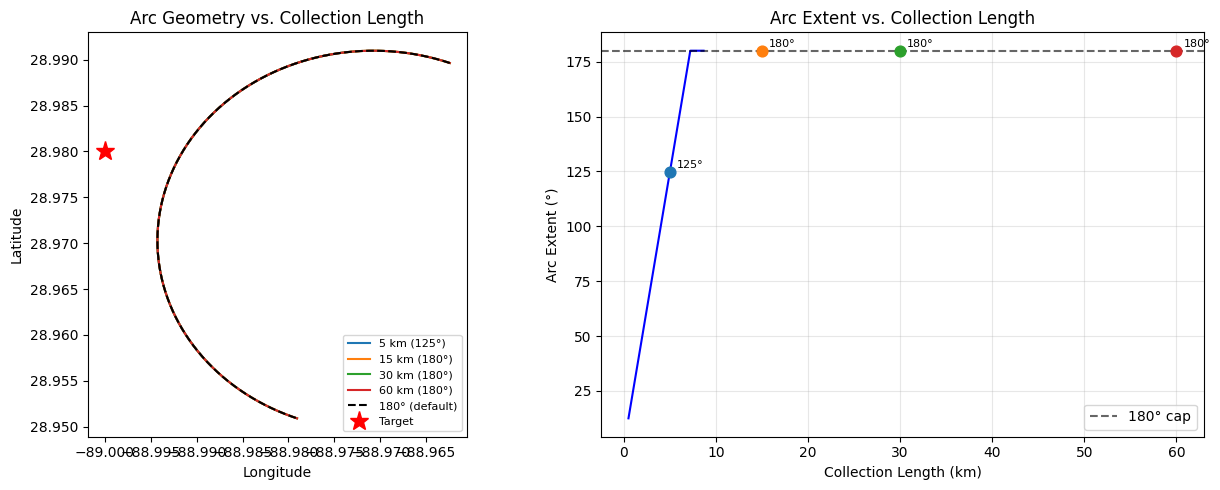

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overlay arc paths at different collection lengths
for a, cl in zip(arcs_cl, collection_lengths_km):
    coords = list(a.geometry.coords)
    axes[0].plot([c[0] for c in coords], [c[1] for c in coords],
                 label=f"{cl} km ({a.arc_extent:.0f}°)")

coords = list(arc.geometry.coords)
axes[0].plot([c[0] for c in coords], [c[1] for c in coords],
             "k--", linewidth=1.5, label=f"180° (default)")
axes[0].plot(target_lon, target_lat, "r*", markersize=14, zorder=5, label="Target")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Arc Geometry vs. Collection Length")
axes[0].legend(fontsize=8)
axes[0].set_aspect("equal")

# Right: arc_extent as a continuous function of collection length
cl_m = np.linspace(500, arc._turn_radius_m * np.pi * 1.2, 300)
extents = np.minimum(np.degrees(cl_m / arc._turn_radius_m), 180.0)
axes[1].plot(cl_m / 1000, extents, "b-")
axes[1].axhline(180, color="k", linestyle="--", alpha=0.6, label="180° cap")
for a_cl, cl in zip(arcs_cl, collection_lengths_km):
    axes[1].scatter(cl, a_cl.arc_extent, zorder=5, s=60)
    axes[1].annotate(
        f"{a_cl.arc_extent:.0f}°",
        (cl, a_cl.arc_extent),
        textcoords="offset points", xytext=(5, 3), fontsize=8,
    )
axes[1].set_xlabel("Collection Length (km)")
axes[1].set_ylabel("Arc Extent (°)")
axes[1].set_title("Arc Extent vs. Collection Length")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Compute Glint Angles Across the Sensor Swath

Use `compute_glint_arc` to sweep the AVIRIS-3 sensor FOV across the arc, computing glint angles at every (along-track, cross-track) position. The sensor is banked with the aircraft, so the effective view zenith in the Earth frame is `bank_angle + sensor_tilt`.

In [7]:
sensor = AVIRIS3()
gdf = compute_glint_arc(arc, sensor)

print(f"Swath points: {len(gdf):,}")
print(f"Min glint angle: {gdf['glint_angle'].min():.2f}")
print(f"Max glint angle: {gdf['glint_angle'].max():.2f}")
print(f"Points with glint < 5:  {(gdf['glint_angle'] < 5).sum():,}")
print(f"Points with glint < 25: {(gdf['glint_angle'] < 25).sum():,}")

Swath points: 14,760
Min glint angle: 0.21
Max glint angle: 36.40
Points with glint < 5:  662
Points with glint < 25: 13,379


### Glint angle map (geographic)

Plot the glint angles on the map, colored by intensity. Points with low glint angles (strong specular reflection) appear in warm colors near the target.

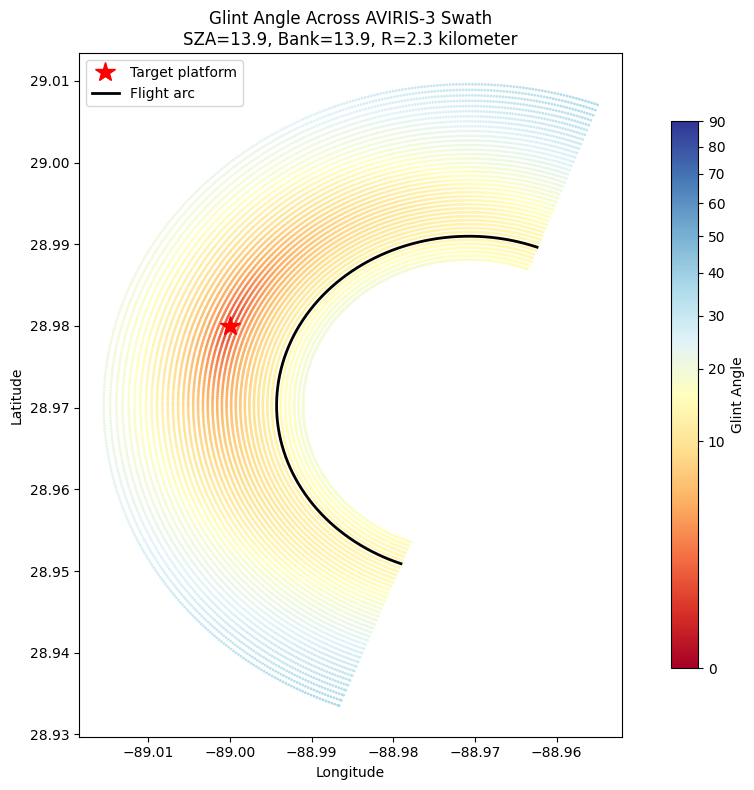

In [8]:
from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    gdf["target_longitude"], gdf["target_latitude"],
    c=gdf["glint_angle"], cmap="RdYlBu", s=1,
    norm=PowerNorm(gamma=0.4, vmin=0, vmax=90),
)
ax.plot(target_lon, target_lat, "r*", markersize=15, label="Target platform")

# Arc flight path
arc_lons = [c[0] for c in arc.geometry.coords]
arc_lats = [c[1] for c in arc.geometry.coords]
ax.plot(arc_lons, arc_lats, "k-", linewidth=2, label="Flight arc")

cb = plt.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("Glint Angle")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Glint Angle Across AVIRIS-3 Swath\n"
    f"SZA={arc.solar_zenith:.1f}, Bank={arc.bank_angle:.1f}, "
    f"R={arc.turn_radius.to('km'):.1f}"
)
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Glint angle in sensor coordinates

View the glint angle as a function of along-track distance and sensor tilt angle. The specular "hot spot" (glint angle ~ 0) should appear at the arc midpoint and near tilt = 0 (where the view zenith equals the bank angle = SZA).

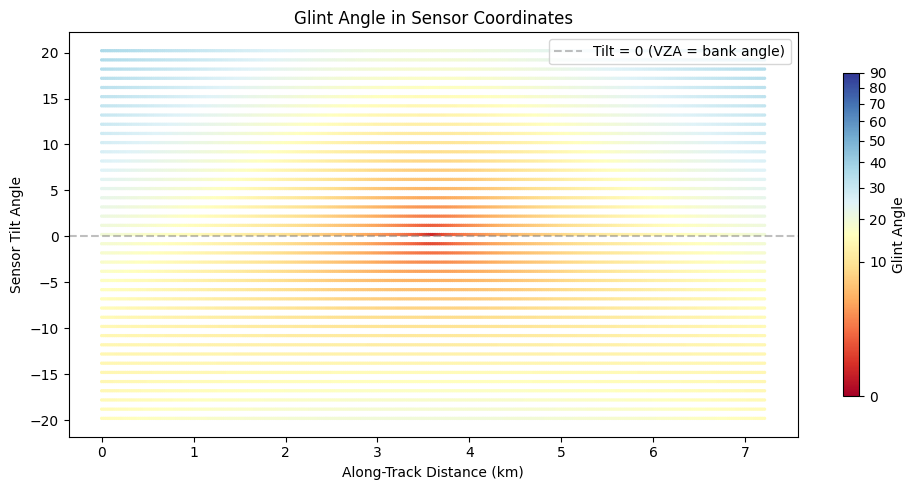

In [9]:
gdf_at = compute_glint_arc(arc, sensor, output_geometry="along_track")

fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    gdf_at["along_track_distance"] / 1000.0,
    gdf_at["tilt_angle"],
    c=gdf_at["glint_angle"], cmap="RdYlBu", s=2,
    norm=PowerNorm(gamma=0.4, vmin=0, vmax=90),
)
cb = plt.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label("Glint Angle")

ax.set_xlabel("Along-Track Distance (km)")
ax.set_ylabel("Sensor Tilt Angle")
ax.set_title("Glint Angle in Sensor Coordinates")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5, label="Tilt = 0 (VZA = bank angle)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Time-of-Day Study

The solar zenith angle changes throughout the day, which changes the required bank angle and turn radius. Explore how the arc geometry varies from morning to afternoon (15:00-20:00 UTC, or 10 AM - 3 PM local CDT).

Hours where SZA > 60 are automatically skipped (bank angle would be too steep); pass `bank_angle` explicitly to override.

In [10]:
hours_utc = np.arange(15, 21)  # 15:00-20:00 UTC
results = []

for h in hours_utc:
    t = datetime(2025, 6, 15, h, 0, tzinfo=timezone.utc)
    try:
        a = GlintArc(
            target_lat=target_lat, target_lon=target_lon,
            observation_datetime=t,
            altitude_msl=ureg.Quantity(10000, "foot"),
            speed=ureg.Quantity(145, "knot"),
        )
        results.append({
            "hour_utc": h,
            "local_time": f"{h - 5}:00",
            "sza": a.solar_zenith,
            "solar_az": a.solar_azimuth,
            "bank_angle": a.bank_angle,
            "turn_radius_km": a.turn_radius.to("km").magnitude,
            "arc_length_km": a.length.to("km").magnitude,
            "heading": a.heading_at_midpoint,
            "arc": a,
        })
    except Exception as e:
        print(f"  {h}:00 UTC -- skipped: {e}")

for r in results:
    print(
        f"{r['local_time']} CDT | SZA={r['sza']:.1f} | "
        f"Bank={r['bank_angle']:.1f} | R={r['turn_radius_km']:.1f} km | "
        f"Arc={r['arc_length_km']:.1f} km | Heading={r['heading']:.0f}"
    )

10:00 CDT | SZA=39.8 | Bank=39.8 | R=0.7 km | Arc=2.1 km | Heading=178
11:00 CDT | SZA=26.7 | Bank=26.7 | R=1.1 km | Arc=3.5 km | Heading=185
12:00 CDT | SZA=13.9 | Bank=13.9 | R=2.3 km | Arc=7.2 km | Heading=201
13:00 CDT | SZA=5.7 | Bank=5.7 | R=5.7 km | Arc=17.9 km | Heading=278
14:00 CDT | SZA=15.3 | Bank=15.3 | R=2.1 km | Arc=6.5 km | Heading=342
15:00 CDT | SZA=28.2 | Bank=28.2 | R=1.1 km | Arc=3.3 km | Heading=356


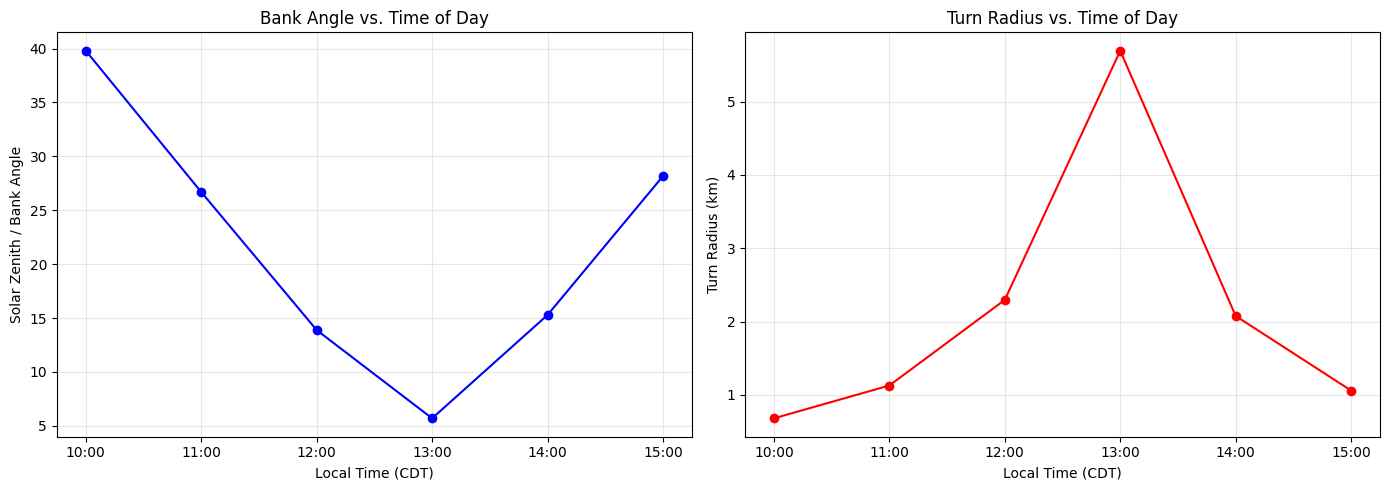

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

local_times = [r["local_time"] for r in results]
szas = [r["sza"] for r in results]
radii = [r["turn_radius_km"] for r in results]

axes[0].plot(local_times, szas, "bo-")
axes[0].set_xlabel("Local Time (CDT)")
axes[0].set_ylabel("Solar Zenith / Bank Angle")
axes[0].set_title("Bank Angle vs. Time of Day")
axes[0].grid(True, alpha=0.3)

axes[1].plot(local_times, radii, "ro-")
axes[1].set_xlabel("Local Time (CDT)")
axes[1].set_ylabel("Turn Radius (km)")
axes[1].set_title("Turn Radius vs. Time of Day")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Arc geometry at different times

Overlay the arc paths for each hour on a single map to see how the arc rotates and changes radius throughout the day.

In [12]:
m2 = folium.Map(location=[target_lat, target_lon], zoom_start=10)

folium.Marker(
    [target_lat, target_lon],
    popup="Target Platform",
    icon=folium.Icon(color="red", icon="industry", prefix="fa"),
).add_to(m2)

colors = ["darkblue", "blue", "green", "orange", "red", "darkred"]
for r, color in zip(results, colors):
    a = r["arc"]
    coords = [(lat, lon) for lon, lat in a.geometry.coords]
    folium.PolyLine(
        coords, color=color, weight=3,
        tooltip=f"{r['local_time']} CDT | SZA={r['sza']:.1f} | R={r['turn_radius_km']:.1f} km",
    ).add_to(m2)

m2

## 5. Compare Left vs. Right Bank

Both bank directions produce valid specular geometry. The aircraft heading differs by 180 -- this affects approach direction and may matter for operational planning.

In [13]:
arc_right = GlintArc(
    target_lat=target_lat, target_lon=target_lon,
    observation_datetime=obs_time,
    altitude_msl=ureg.Quantity(10000, "foot"),
    speed=ureg.Quantity(145, "knot"),
    bank_direction="right",
)

arc_left = GlintArc(
    target_lat=target_lat, target_lon=target_lon,
    observation_datetime=obs_time,
    altitude_msl=ureg.Quantity(10000, "foot"),
    speed=ureg.Quantity(145, "knot"),
    bank_direction="left",
)

m3 = folium.Map(location=[target_lat, target_lon], zoom_start=12)

folium.Marker(
    [target_lat, target_lon],
    popup="Target", icon=folium.Icon(color="red", icon="industry", prefix="fa"),
).add_to(m3)

for a, color, label in [(arc_right, "blue", "Right bank"), (arc_left, "green", "Left bank")]:
    coords = [(lat, lon) for lon, lat in a.geometry.coords]
    folium.PolyLine(
        coords, color=color, weight=3,
        tooltip=f"{label}: heading={a.heading_at_midpoint:.0f}",
    ).add_to(m3)

print(f"Right bank heading: {arc_right.heading_at_midpoint:.0f}")
print(f"Left bank heading:  {arc_left.heading_at_midpoint:.0f}")
m3

Right bank heading: 201
Left bank heading:  21


## 7. Approach and Exit Lines

`approach_line(length)` and `exit_line(length)` return straight `FlightLine` segments that connect to the arc **tangentially** — the heading at the junction matches the arc tangent exactly, producing a smooth entry and exit.

```
entry point  ──[approach]──▶  [arc]  ──[exit]──▶  exit point
```

Both lines share the aircraft's altitude and can be passed directly into `compute_flight_plan` alongside the arc waypoints to build a complete mission route.

In [14]:
approach_length = ureg.Quantity(10, "km")

approach = arc.approach_line(approach_length)
exit_fl   = arc.exit_line(approach_length)

print("Approach line:")
print(f"  Entry point:  ({approach.waypoint1.latitude:.4f}, {approach.waypoint1.longitude:.4f})  hdg={approach.waypoint1.heading:.1f}°")
print(f"  Arc start:    ({approach.waypoint2.latitude:.4f}, {approach.waypoint2.longitude:.4f})  hdg={approach.waypoint2.heading:.1f}°")
print()
print("Arc:")
print(f"  Start:        ({arc.waypoint1.latitude:.4f}, {arc.waypoint1.longitude:.4f})  hdg={arc.waypoint1.heading:.1f}°")
print(f"  Midpoint:     ({arc._aircraft_mid_lat:.4f}, {arc._aircraft_mid_lon:.4f})  hdg={arc.heading_at_midpoint:.1f}°  ← perfect specular")
print(f"  End:          ({arc.waypoint2.latitude:.4f}, {arc.waypoint2.longitude:.4f})  hdg={arc.waypoint2.heading:.1f}°")
print()
print("Exit line:")
print(f"  Arc end:      ({exit_fl.waypoint1.latitude:.4f}, {exit_fl.waypoint1.longitude:.4f})  hdg={exit_fl.waypoint1.heading:.1f}°")
print(f"  Exit point:   ({exit_fl.waypoint2.latitude:.4f}, {exit_fl.waypoint2.longitude:.4f})  hdg={exit_fl.waypoint2.heading:.1f}°")

Approach line:
  Entry point:  (28.9581, -88.8663)  hdg=290.5°
  Arc start:    (28.9896, -88.9624)  hdg=290.4°

Arc:
  Start:        (28.9896, -88.9624)  hdg=290.5°
  Midpoint:     (28.9776, 271.0072)  hdg=200.7°  ← perfect specular
  End:          (28.9509, -88.9791)  hdg=111.0°

Exit line:
  Arc end:      (28.9509, -88.9791)  hdg=111.0°
  Exit point:   (28.9186, -88.8833)  hdg=111.0°


In [15]:
m4 = folium.Map(location=[target_lat, target_lon], zoom_start=11)

# Approach line
folium.PolyLine(
    [(approach.waypoint1.latitude, approach.waypoint1.longitude),
     (approach.waypoint2.latitude, approach.waypoint2.longitude)],
    color="green", weight=4, tooltip="Approach",
).add_to(m4)

# Arc
arc_coords = [(lat, lon) for lon, lat in arc.geometry.coords]
folium.PolyLine(arc_coords, color="blue", weight=4, tooltip="Collection arc").add_to(m4)

# Exit line
folium.PolyLine(
    [(exit_fl.waypoint1.latitude, exit_fl.waypoint1.longitude),
     (exit_fl.waypoint2.latitude, exit_fl.waypoint2.longitude)],
    color="darkorange", weight=4, tooltip="Exit",
).add_to(m4)

# Target
folium.Marker(
    [target_lat, target_lon],
    popup="Target platform",
    icon=folium.Icon(color="red", icon="industry", prefix="fa"),
).add_to(m4)

# Key waypoints
for wp, label in [
    (approach.waypoint1, "Entry point"),
    (arc.waypoint1,      "Arc start"),
    (arc.waypoint2,      "Arc end"),
    (exit_fl.waypoint2,  "Exit point"),
]:
    folium.CircleMarker(
        [wp.latitude, wp.longitude],
        radius=6, color="black", fill=True, fill_color="white", fill_opacity=0.9,
        tooltip=f"{label}  hdg={wp.heading:.0f}°",
    ).add_to(m4)

m4

## 8. Ground Swath Footprint

`footprint(sensor)` returns a Shapely `Polygon` of the sensor's ground coverage across the entire arc. For each sampled arc position the near and far swath edges are ray-cast to the Earth surface using the aircraft altitude, bank angle, and sensor half-angle. The two edge tracks are joined into a closed polygon.

At the arc midpoint the sensor is looking directly at the target, so the footprint always encloses the target location. When the near edge crosses nadir (bank angle < sensor half-angle), the view azimuth flips automatically.

In [16]:
footprint_poly = arc.footprint(sensor)

near_vza = arc.bank_angle - sensor.half_angle
far_vza  = arc.bank_angle + sensor.half_angle

print(f"Sensor half-angle:  {sensor.half_angle}°  (full FOV {sensor.half_angle * 2}°)")
print(f"Bank angle:         {arc.bank_angle:.1f}°")
print(f"Near edge VZA:      {near_vza:.1f}°  {'(crosses nadir — azimuth flipped)' if near_vza < 0 else ''}")
print(f"Far edge VZA:       {far_vza:.1f}°")
print(f"Footprint valid:    {footprint_poly.is_valid}")

# Area in km² (approximate at this latitude)
cos_lat = np.cos(np.radians(target_lat))
area_km2 = footprint_poly.area * 111.32 * 111.32 * cos_lat
print(f"Footprint area:     {area_km2:.1f} km²")

Sensor half-angle:  19.8°  (full FOV 39.6°)
Bank angle:         13.9°
Near edge VZA:      -5.9°  (crosses nadir — azimuth flipped)
Far edge VZA:       33.7°
Footprint valid:    True
Footprint area:     23.3 km²


In [17]:
m5 = folium.Map(location=[target_lat, target_lon], zoom_start=11)

# Swath footprint polygon
poly_coords = [(lat, lon) for lon, lat in footprint_poly.exterior.coords]
folium.Polygon(
    poly_coords,
    color="purple", weight=2,
    fill=True, fill_color="purple", fill_opacity=0.2,
    tooltip=f"Swath footprint  ({sensor.half_angle * 2:.0f}° FOV,  {area_km2:.0f} km²)",
).add_to(m5)

# Arc flight path
arc_coords = [(lat, lon) for lon, lat in arc.geometry.coords]
folium.PolyLine(arc_coords, color="blue", weight=3, tooltip="Flight arc").add_to(m5)

# Target
folium.Marker(
    [target_lat, target_lon],
    popup="Target platform",
    icon=folium.Icon(color="red", icon="industry", prefix="fa"),
).add_to(m5)

m5

## 9. Export

Export arc geometry, glint swath data, and flight lines in formats suitable for GIS software and scanner mission planning.

- **GeoJSON** — arc path and per-pixel glint swath, ready for QGIS / web maps  
- **TrackAir** — INI-style scanner planning file for HyMap/HySpex; the `[strips]` section lists the approach and exit flight lines that the sensor operator loads into the scanner control software

In [18]:
import json

from hyplan import DynamicAviation_B200, compute_flight_plan
from hyplan.exports import to_trackair

# --- GeoJSON: arc path and glint swath ---
with open("glint_arc_path.geojson", "w") as f:
    json.dump(arc.to_geojson(), f, indent=2)

gdf.to_file("glint_arc_swath.geojson", driver="GeoJSON")

print("Exported: glint_arc_path.geojson")
print("Exported: glint_arc_swath.geojson")

# --- TrackAir: approach and exit flight lines for scanner planning ---
aircraft = DynamicAviation_B200()
plan = compute_flight_plan(aircraft, [approach, exit_fl])

to_trackair(
    plan,
    "glint_arc_trackair.txt",
    sensor=sensor,
    mission_name="GOM_GLINT_20250615",
    author="HyPlan",
)
print("Exported: glint_arc_trackair.txt")

# Preview the TrackAir output
with open("glint_arc_trackair.txt") as f:
    print("\n--- TrackAir preview ---")
    print(f.read())

Exported: glint_arc_path.geojson
Exported: glint_arc_swath.geojson
Exported: glint_arc_trackair.txt

--- TrackAir preview ---
[general]
Project name =

Coordinate system = World geographic latitude-longitude
Datum =

Flight plan name = GOM_GLINT_20250615
Export flight plan = no
Designed by = HyPlan

[spex]
'DO NOT EDIT THESE PARAMETERS HERE, USE THE SCANNER MENU.
Type of planning = LINE SCANNER PLANNING
Field of view = 39.6
Flying height agl (meters) = 3048
Swath width (meters) = 2194

Designed by = HyPlan

[strips]
1=28.928820000000005,-88.77732000000003,28.995404999998343,-88.98024699999485
2=28.980758999999995,-89.06779499999999,28.91259900000182,-88.86557500000532

